In [1]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm , Normalize


In [2]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters('../parametri.txt')


# --- Parametri Geometrici ---
R_CORE    = p['R_CORE']
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']

# --- Parametri Logici ---
R_PIPE    = p['R_PIPE']

# --- Parametri Pin/Lattice ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']
PITCH     = p['PITCH']

# --- Parametri Target ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']

# --- Sorgente e Simulazione ---
S             = p['S']

bin_ris       = p['bin_ris']
batches       = p['batches']
particles     = p['particles']
inactive      = p['inactive']
arricchimento = p['arricchimento']

In [3]:
#Apertura delle tallies
sp = openmc.StatePoint(f'statepoint.{batches}.h5')

Profilo Neutronico e fotonico lungo l'asse del reattore

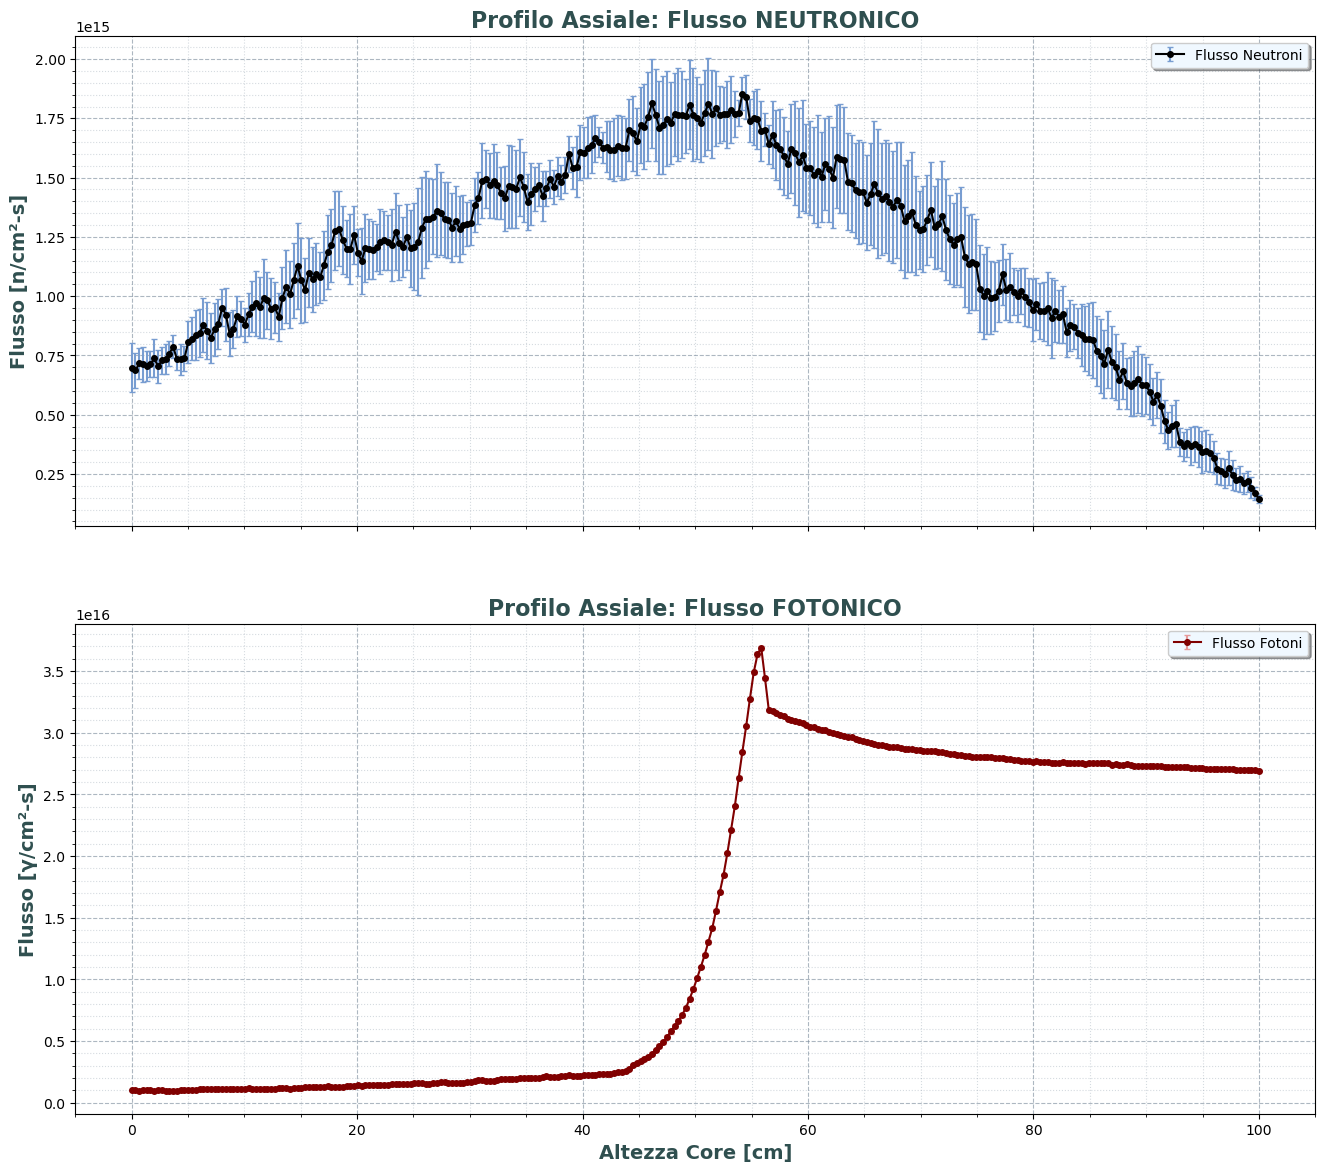

In [4]:
t_n = sp.get_tally(name='profilo_neutroni')
t_p = sp.get_tally(name='profilo_fotoni')

# Neutroni
n_mean = t_n.get_values(scores=['flux'], value='mean').flatten() * S
n_std  = t_n.get_values(scores=['flux'], value='std_dev').flatten() * S
# Fotoni
p_mean = t_p.get_values(scores=['flux'], value='mean').flatten() * S
p_std  = t_p.get_values(scores=['flux'], value='std_dev').flatten() * S

# Asse Z
z_coords = np.linspace(0.0, 100.0, len(n_mean))

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14), sharex=True)
plt.subplots_adjust(hspace=0.2)

# --- PLOT 1: NEUTRONI ---
ax1.errorbar(z_coords, n_mean, yerr=n_std, fmt='-o', markersize=4,
             color='#000000', ecolor='#789DD1', capsize=2, label='Flusso Neutroni')
ax1.set_title('Profilo Assiale: Flusso NEUTRONICO', fontsize=16, fontweight='bold', color='#2F4F4F')
ax1.set_ylabel('Flusso [n/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_xlabel('Altezza Core [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax1.minorticks_on()
ax1.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax1.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax1.legend(loc='upper right', frameon=True, shadow=True, facecolor='#F0F8FF')

# --- PLOT 2: FOTONI ---
ax2.errorbar(z_coords, p_mean, yerr=p_std, fmt='-o', markersize=4,
             color='#800000', ecolor='#E69999', capsize=2, label='Flusso Fotoni')
ax2.set_title('Profilo Assiale: Flusso FOTONICO', fontsize=16, fontweight='bold', color='#2F4F4F')
ax2.set_xlabel('Altezza Core [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_ylabel('Flusso [γ/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.minorticks_on()
ax2.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax2.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax2.legend(loc='upper right', frameon=True, shadow=True, facecolor='#F0F8FF')

plt.show()

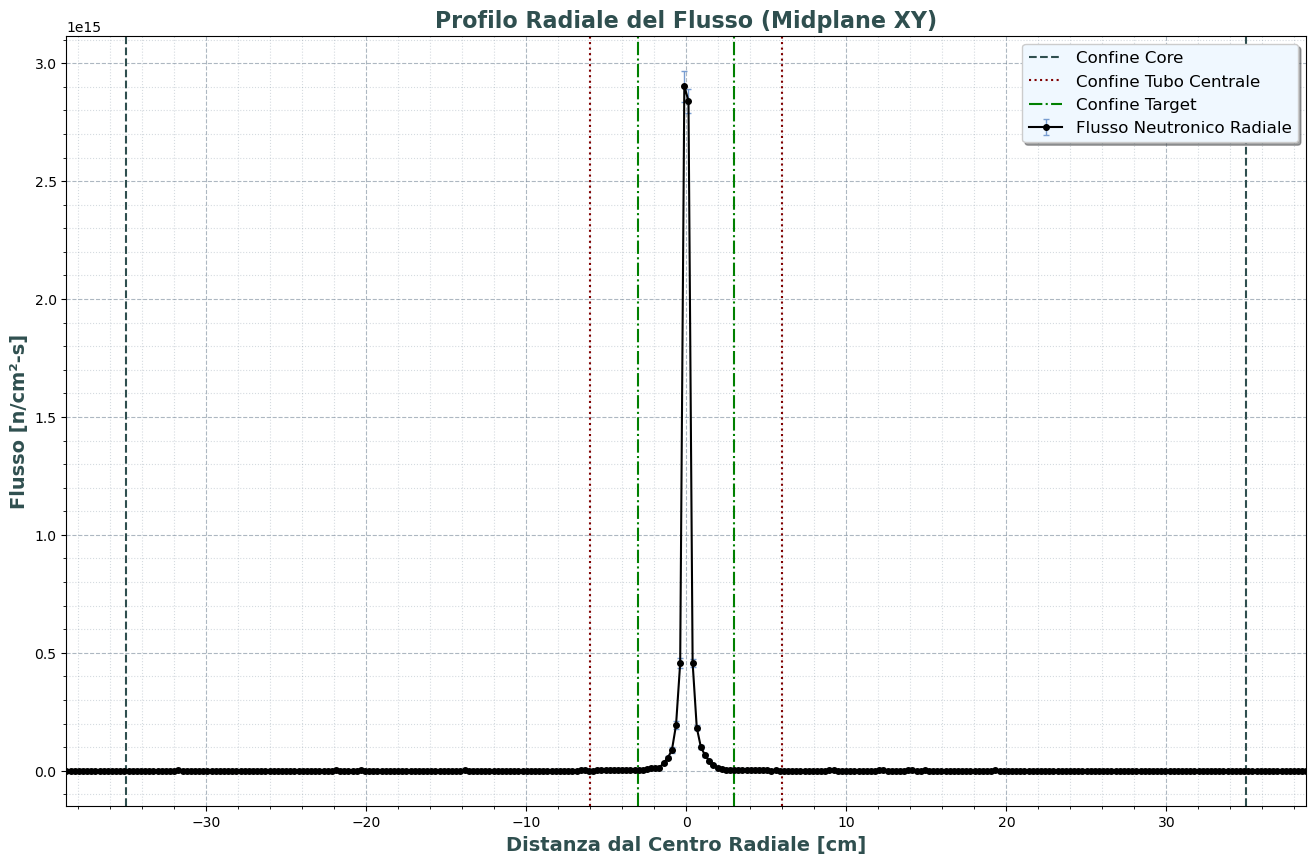

In [5]:
tally_xy_res = sp.get_tally(name='mappa_fissioni')

# Estraiamo il flusso e calcoliamo la deviazione standard per coerenza stilistica
flux_xy = tally_xy_res.get_values(scores=['flux'], value='mean').reshape((bin_ris, bin_ris))
flux_std = tally_xy_res.get_values(scores=['flux'], value='std_dev').reshape((bin_ris, bin_ris))

# Normalizzazione con l'intensità della sorgente S
flux_xy *= S
flux_std *= S

# --- SLICING (Taglio centrale lungo l'asse X) ---
mid_index = flux_xy.shape[0] // 2
flux_radial = flux_xy[mid_index, :]
std_radial = flux_std[mid_index, :]

# Creazione asse X centrato
bound_xy = R_CORE + REF_SIDE/4
x_coords = np.linspace(-bound_xy, bound_xy, bin_ris)

# --- PLOTTING ---
plt.figure(figsize=(16, 10))

plt.errorbar(x_coords, flux_radial, yerr=std_radial, fmt='-o', markersize=4,
             color='#000000', ecolor='#789DD1', capsize=2, elinewidth=1, 
             label='Flusso Neutronico Radiale')

# Linee verticali di riferimento per i confini fisici 
plt.axvline(x=-R_CORE, color='#2F4F4F', linestyle='--', alpha=1, label='Confine Core')
plt.axvline(x=R_CORE, color='#2F4F4F', linestyle='--', alpha=1)
plt.axvline(x=-R_PIPE, color='#800000', linestyle=':', alpha=1, label='Confine Tubo Centrale')
plt.axvline(x=R_PIPE, color='#800000', linestyle=':', alpha=1)
plt.axvline(x=-R_TARGET, color='#008000', linestyle='-.', alpha=1, label='Confine Target')
plt.axvline(x=R_TARGET, color='#008000', linestyle='-.', alpha=1)

# --- FORMATTAZIONE TOOLKIT ---
plt.title('Profilo Radiale del Flusso (Midplane XY)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('Distanza dal Centro Radiale [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Flusso [n/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.xlim(-bound_xy, bound_xy)

plt.show()

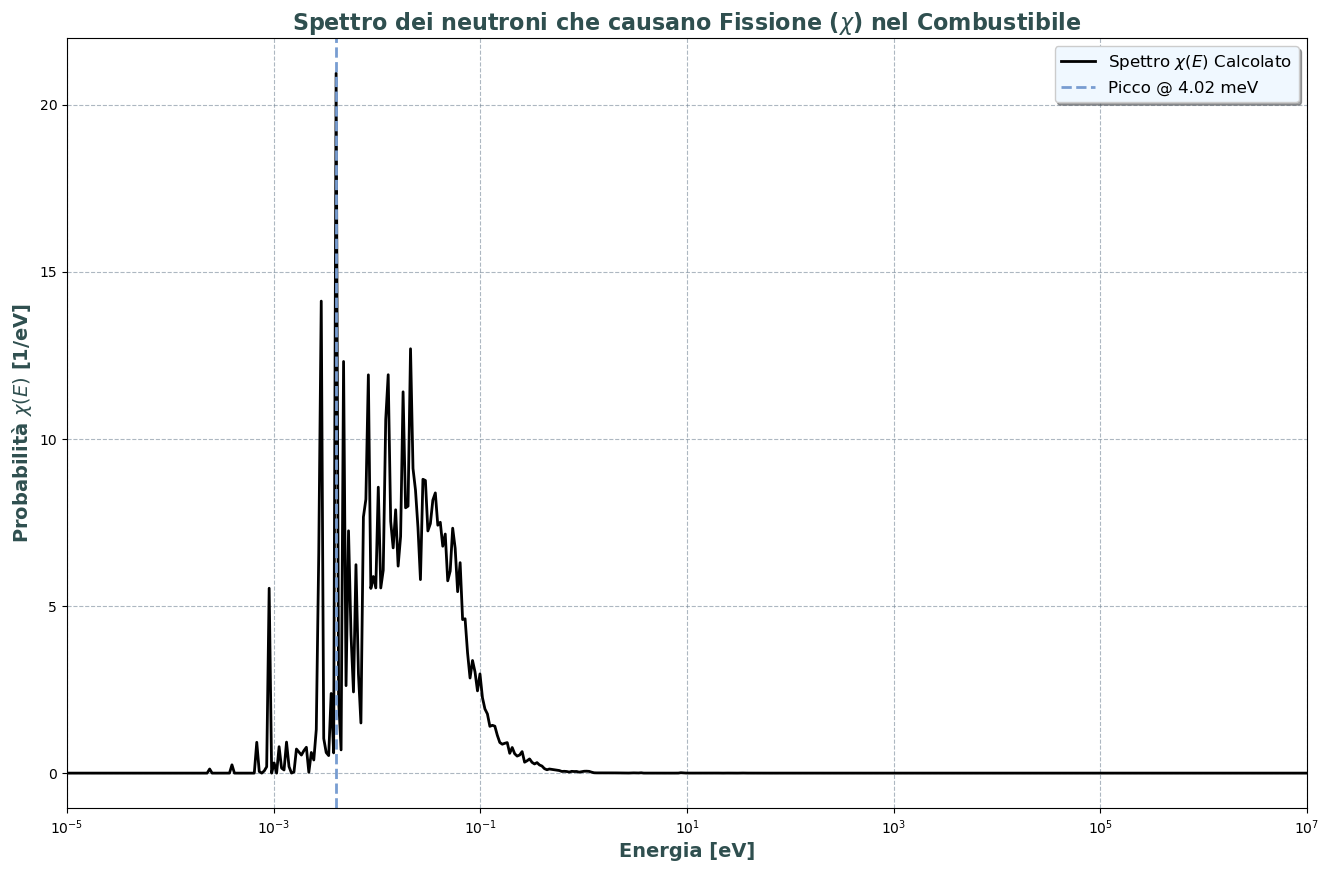

In [6]:
tally_chi_res = sp.get_tally(name='spettro_chi')

# Estraiamo i dati grezzi (nu-fission rate per bin energetico)
# La shape sarà (Num_Energy_Bins, 1, 1) -> appiattiamo a 1D
chi_spectrum = tally_chi_res.get_values(scores=['nu-fission'], value='mean').flatten()

# --- ELABORAZIONE FISICA (Normalizzazione PDF) ---
# Per ottenere la PDF Chi(E), dobbiamo dividere per la larghezza del bin (dE)
# e normalizzare l'area totale a 1.

# 1. Recupero la griglia energetica usata nel filtro
energy_bins = np.logspace(-5, 7, 501) # Deve matchare la definizione originale
energy_mid = (energy_bins[1:] + energy_bins[:-1]) / 2 # Punti medi per il plot
dE = np.diff(energy_bins) # Larghezza dei bin

# 2. Calcolo della densità spettrale (Rate / dE)
chi_density = chi_spectrum / dE

# 3. Normalizzazione integrale (Area = 1)
# L'integrale si approssima come somma(density * dE) = somma(spectrum)
integral = np.sum(chi_spectrum)
if integral > 0:
    chi_normalized = chi_density / integral
else:
    chi_normalized = chi_density # Evita divisione per zero se vuoto

# --- PLOTTING ---
plt.figure(figsize=(16, 10))
plt.plot(energy_mid, chi_normalized, color='#000000', linewidth=2, label=r'Spettro $\chi(E)$ Calcolato')

# Formattazione
plt.title(r'Spettro dei neutroni che causano Fissione ($\chi$) nel Combustibile', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('Energia [eV]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel(r'Probabilità $\chi(E)$ [1/eV]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Scala assi
plt.xscale('log')

# Aggiungiamo una linea per evidenziare il picco
peak_energy = energy_mid[np.argmax(chi_normalized)]
plt.axvline(x=peak_energy, color='#789DD1', linestyle='--', linewidth=2, label=f'Picco @ {peak_energy*1000:.2f} meV')
plt.xlim(1e-5, 1e7)

# Legenda
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# Griglia
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()

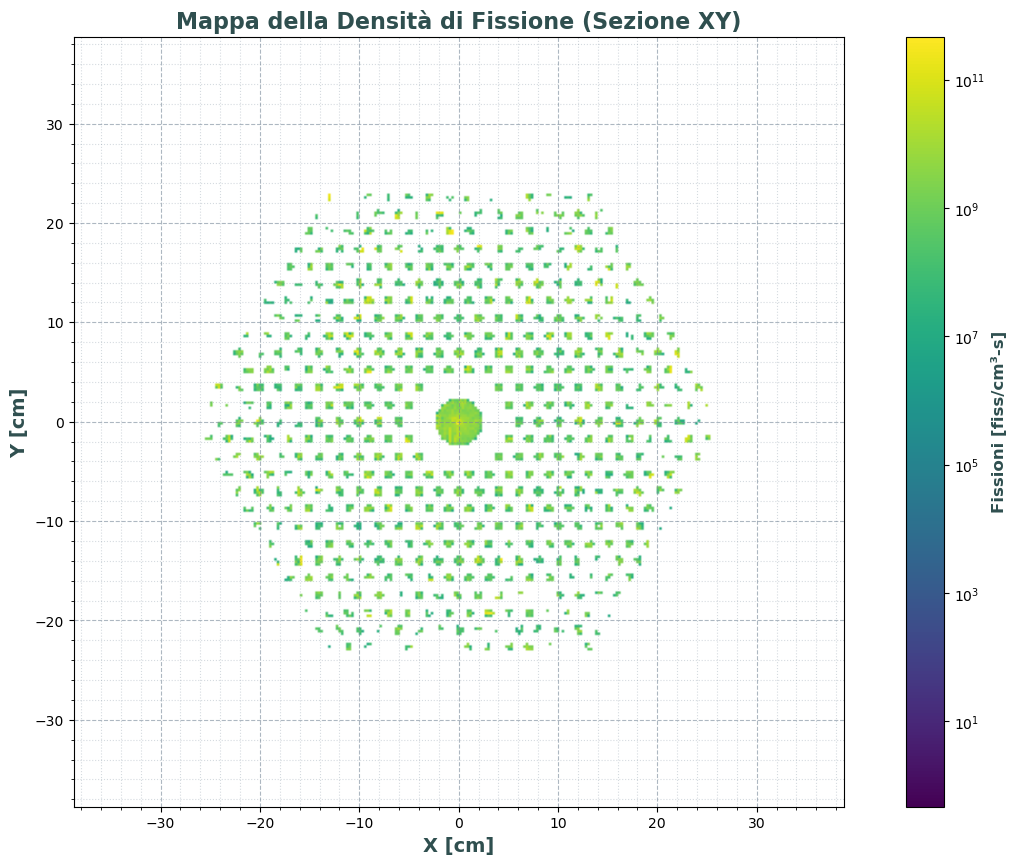

In [7]:
tally = sp.get_tally(name='mappa_fissioni')

# Estrazione e Mascheramento
data = tally.get_values(scores=['fission'], value='mean').reshape((bin_ris,bin_ris))

# Assumo che 'data', 'S', 'R_CORE', 'REF_SIDE' siano già definiti come nel tuo snippet
# Ricalcolo il mascheramento per sicurezza
data_masked = np.where(data > 1e-10, data, np.nan)
data_masked *= S # Applica fattore di scala se non già fatto su 'data' grezzo

# --- CALCOLO LIMITI PER IL PLOT ---
# Calcola il massimo reale della distribuzione
val_max = np.nanmax(data_masked)

# Imposta il minimo a 4 ordini di grandezza sotto il massimo
# Questo evidenzia i gradienti nel combustibile tagliando il rumore di fondo
val_min = val_max * 1e-12 

# PLOTTING
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE/4 

# Setup colormap
cmap = plt.cm.viridis
cmap.set_bad(color='white') 

# Imshow con vmin e vmax forzati
img = plt.imshow(data_masked, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy], 
                 cmap=cmap, origin='lower',
                 norm=LogNorm(vmin=val_min, vmax=val_max)) 

# Formattazione Stile Unificato
plt.title('Mappa della Densità di Fissione (Sezione XY)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar = plt.colorbar(img)
cbar.set_label('Fissioni [fiss/cm³-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia personalizzata
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()

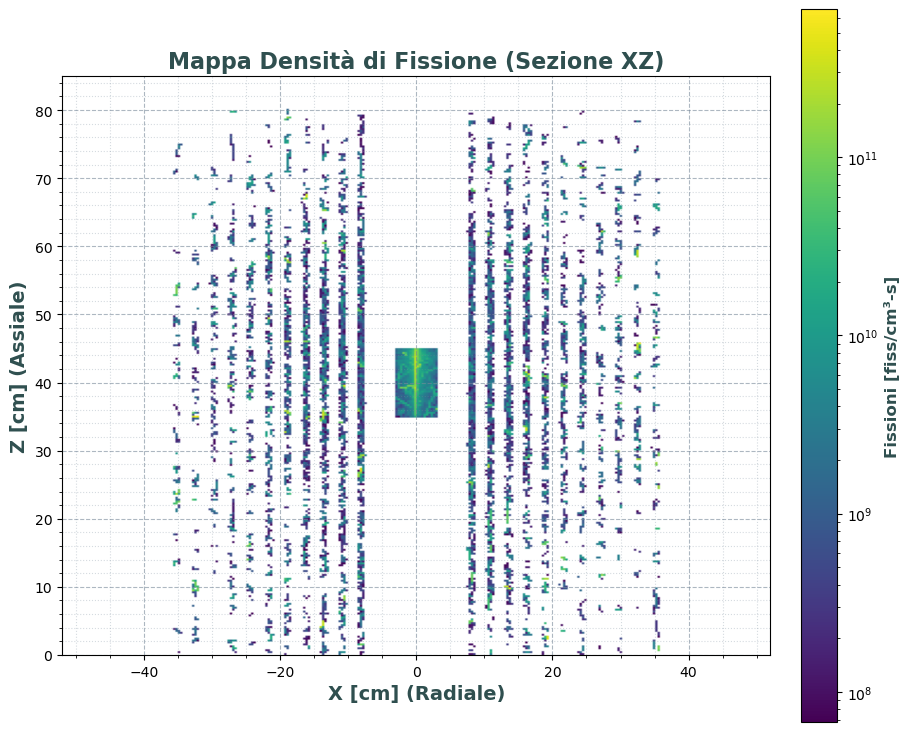

In [8]:

# --- RECUPERO DATI XZ ---
# Assumo tally_xz_res, S, R_CORE, REF_SIDE, H_CORE, bin_ris siano definiti
tally_xz_res = sp.get_tally(name='mappa_fissioni_xz')

data_xz = tally_xz_res.get_values(scores=['fission'], value='mean').reshape((bin_ris, bin_ris))
data_xz = data_xz * S 

# --- CALCOLO RANGE DINAMICO ---
val_max = np.nanmax(data_xz)
val_min = val_max * 1e-4 # 4 ordini di grandezza di range dinamico

# Mascheramento: rende trasparente (bianco) tutto ciò che è sotto la soglia utile
data_xz_masked = np.where(data_xz > val_min, data_xz, np.nan)

# --- PLOTTING ---
plt.figure(figsize=(10, 18)) # Verticale per la vista laterale

bound_x = R_CORE + REF_SIDE + 2.0
bound_z = H_CORE + 5.0

# Colormap
cmap = plt.cm.viridis
cmap.set_bad(color='white')

# Imshow con vmin/vmax bloccati
img = plt.imshow(data_xz_masked, 
                 extent=[-bound_x, bound_x, 0, bound_z], 
                 cmap=cmap, 
                 origin='lower',
                 norm=LogNorm(vmin=val_min, vmax=val_max))


# --- FORMATTAZIONE STILE UNIFICATO ---
plt.title('Mappa Densità di Fissione (Sezione XZ)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm] (Radiale)', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Z [cm] (Assiale)', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
cbar.set_label('Fissioni [fiss/cm³-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()

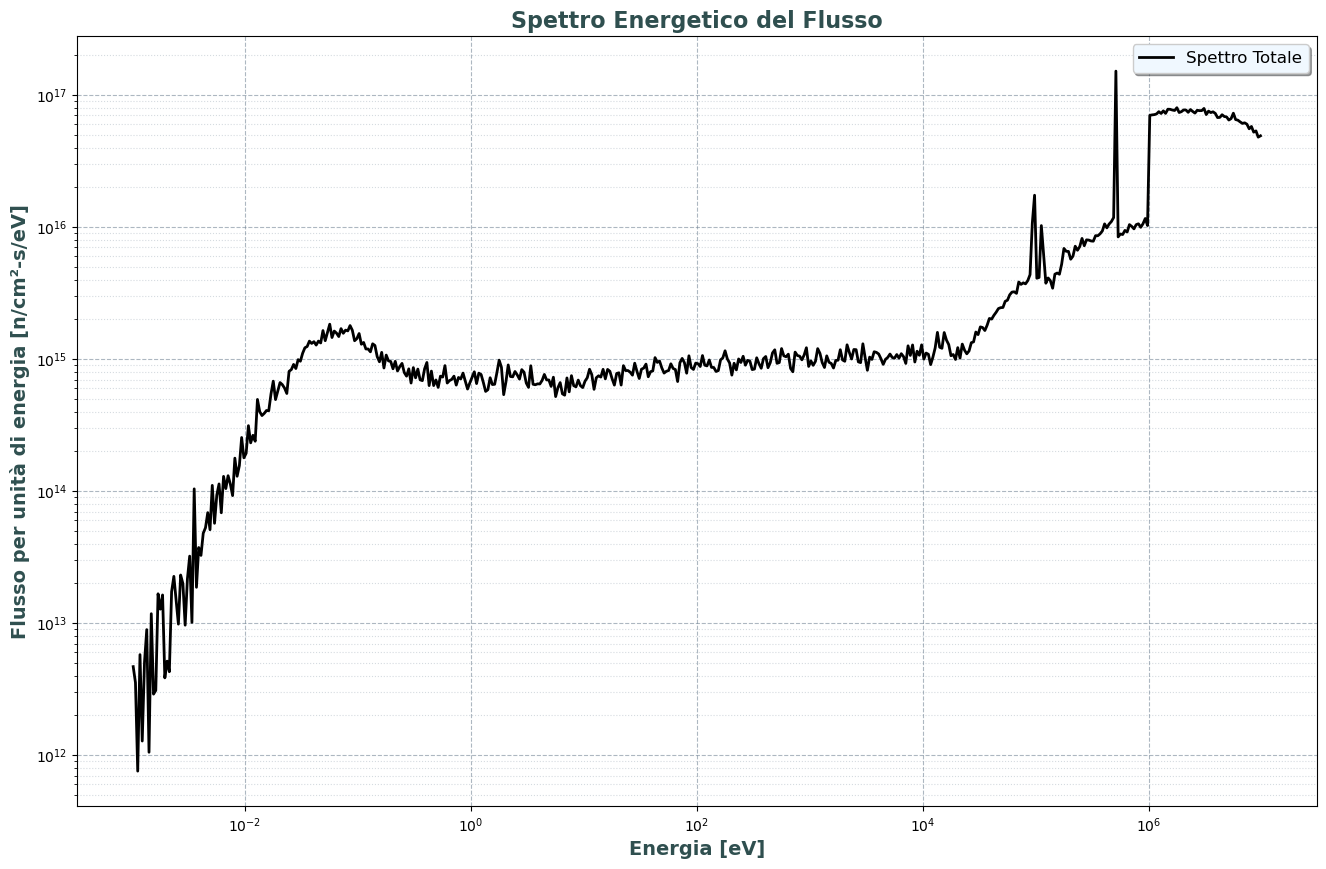

In [9]:
# B. Spettro Energetico (Flux vs Energy)
tally_spec_res = sp.get_tally(name='spettro_energetico')
flux_spectrum = tally_spec_res.get_values(scores=['flux'], value='mean').flatten()
flux_spectrum *= S

# Gestione asse energetico (Logspace ha 501 punti -> 500 bin)
# Usiamo i punti medi dei bin per il plot
energy_bins = np.logspace(-3, 7, 501) # eV
energy_mid = (energy_bins[1:] + energy_bins[:-1]) / 2
energy_width = np.diff(energy_bins) # dE

# Calcolo Flusso per unità di letargia (o densità spettrale): Phi(E) / dE
# Questo rende l'integrale visivo corretto in scala log
flux_per_ev = flux_spectrum

plt.figure(figsize=(16, 10))

plt.loglog(energy_mid, flux_per_ev, color='#000000', linewidth=2, label='Spettro Totale')

plt.title('Spettro Energetico del Flusso', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('Energia [eV]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Flusso per unità di energia [n/cm²-s/eV]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Legenda personalizzata
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# Griglia
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()

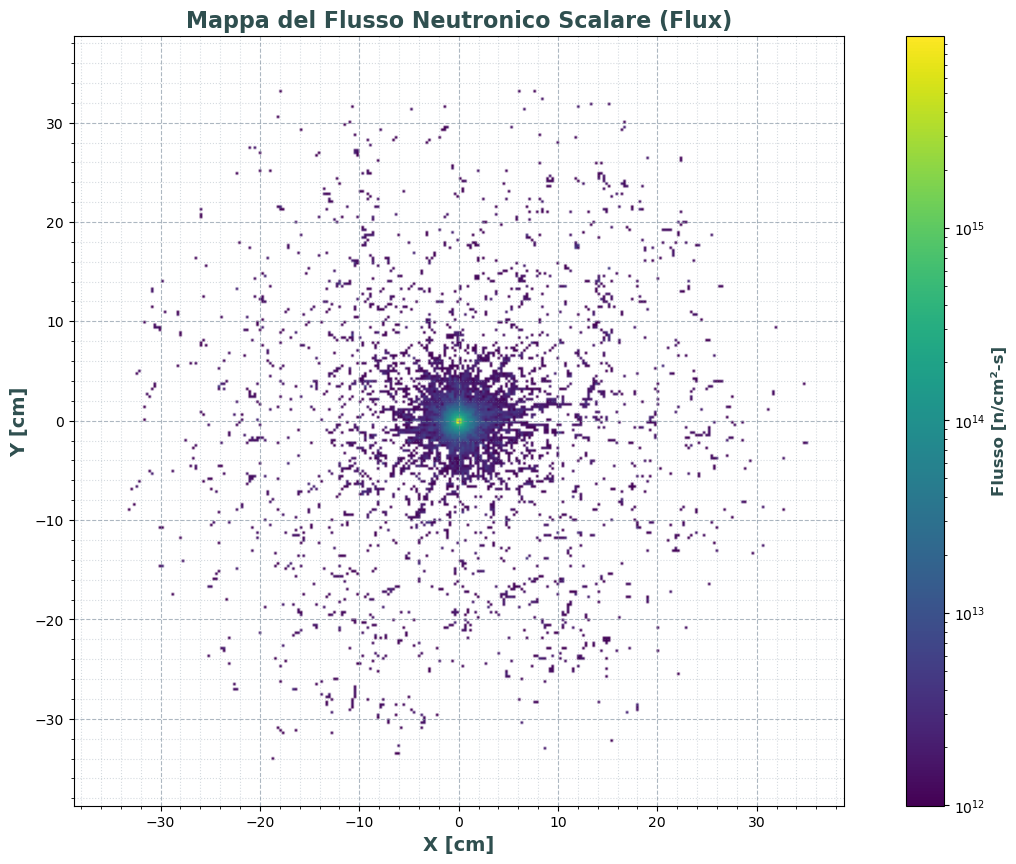

In [10]:
# --- 1. ESTRAZIONE DATI ---
tally_map_res = sp.get_tally(name='mappa_fissioni')

# Estrazione flux e reshape
flux_data = tally_map_res.get_values(scores=['flux'], value='mean').reshape((bin_ris, bin_ris))
flux_data *= S  # Normalizzazione con la sorgente

# --- CALCOLO RANGE DINAMICO ---
# 1. Trova il valore massimo reale (il picco di flusso)
val_max = np.nanmax(flux_data)

# 2. Imposta il minimo a 4 ordini di grandezza sotto il massimo
#    Questo evita che il "rumore" di fondo (es. 1e-10) schiacci la scala colori
val_min = val_max * 1e-4 

# 3. Maschera i valori sotto la soglia minima (diventano bianchi/trasparenti)
flux_masked = np.where(flux_data > val_min, flux_data, np.nan)


# --- 2. PLOTTING ---
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE / 4 

# Setup Colormap
cmap = plt.cm.viridis
cmap.set_bad(color='white')

# Imshow con vmin e vmax forzati
img = plt.imshow(flux_masked, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy],
                 cmap=cmap, origin='lower',
                 norm=LogNorm(vmin=val_min, vmax=val_max)) 

# Formattazione
plt.title('Mappa del Flusso Neutronico Scalare (Flux)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar = plt.colorbar(img)
cbar.set_label('Flusso [n/cm²-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()


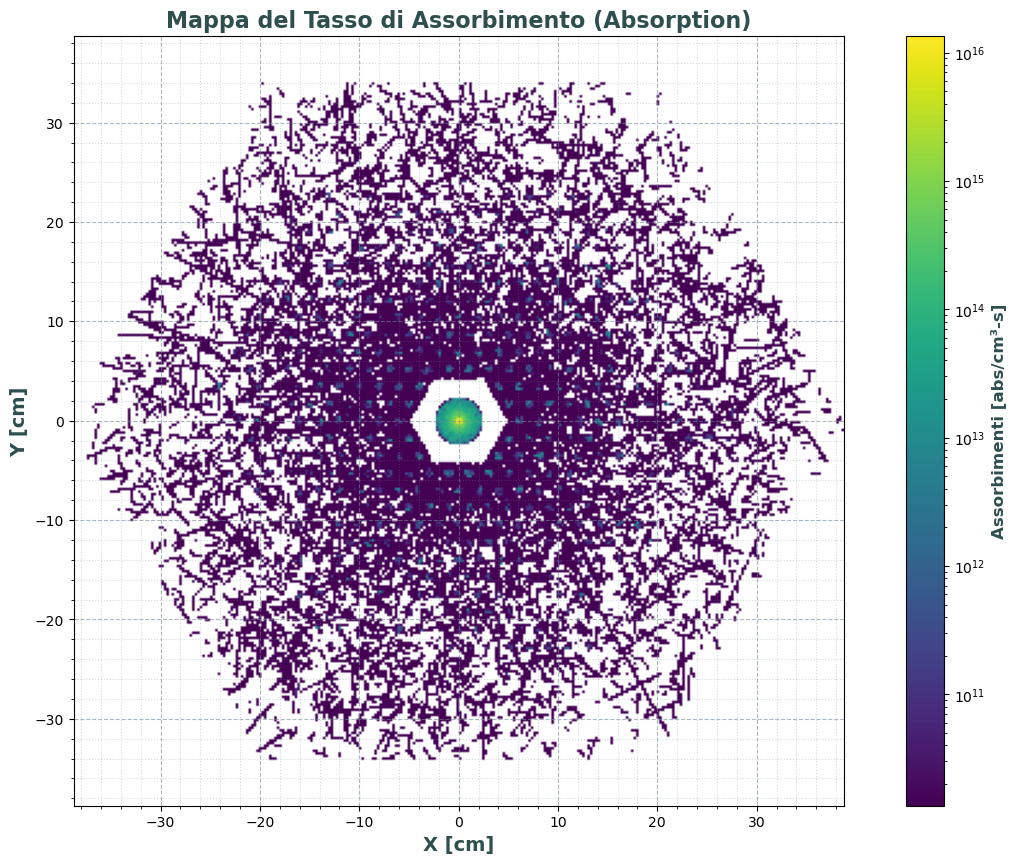

In [11]:
# --- RECUPERO DATI ---
tally_res = sp.get_tally(name='mappa_fissioni')

# 1. Estrazione Assorbimento
abs_data = tally_res.get_values(scores=['absorption'], value='mean').reshape((bin_ris, bin_ris))
abs_data *= S # Normalizzazione con la sorgente

# --- MASCHERE ---
# Imposta i limiti fissi richiesti
limit_min = 1e6
limit_max = 1e20

# Applica la maschera: 
# Mantiene i dati dove (abs_data > 1e6) AND (abs_data < 1e12)
# Altrove assegna NaN (che non viene plottato da matplotlib/imshow)
abs_masked = np.where((abs_data > limit_min) & (abs_data < limit_max), abs_data, np.nan)

val_max = np.nanmax(abs_masked)
val_min = val_max * 1e-6 # 6 ordini di grandezza di range dinamico


# ==========================================
# PLOT 1: TASSO DI ASSORBIMENTO (Log Scale)
# ==========================================
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE / 4 # Uniformo l'extent agli altri plot
cmap = plt.cm.viridis
cmap.set_bad(color='white')

img1 = plt.imshow(abs_masked, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy], 
                  cmap=cmap, origin='lower',
                  norm=LogNorm(vmin=val_min, vmax=val_max)) # Range forzato

# Stile
plt.title('Mappa del Tasso di Assorbimento (Absorption)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar1 = plt.colorbar(img1)
cbar1.set_label('Assorbimenti [abs/cm³-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()
